In [1]:
import pandas as pd
import numpy as np 
import os

In [2]:
df = pd.read_csv(r'C:\Users\eloor\Downloads\Project 12-20260306T051523Z-3-001\Project 12\labeled_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [4]:
df.shape

(24783, 7)

In [5]:
df.describe()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


In [6]:
df["labels"] = df["class"].map({
    0: "Hate",
    1: "Offensive",
    2: "Neutral"
})

In [7]:
df

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,labels
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,Neutral
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive
...,...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an...",Neutral
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...,Offensive
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies,Offensive


# Text Preprocessing

In [8]:

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove user mentions and hashtags
    text = re.sub(r'@\w+|#', '', text)
    
    # Remove punctuation, numbers, and non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize and remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    # Stemming
    words = [stemmer.stem(word) for word in words]
    
    # Join back into string
    return ' '.join(words)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\eloor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
df['clean_tweet'] = df['tweet'].apply(preprocess_text)
df.head()


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,labels,clean_tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,Neutral,rt woman shouldnt complain clean hous amp man ...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive,rt boy dat coldtyga dwn bad cuffin dat hoe st ...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive,rt dawg rt ever fuck bitch start cri confus shit
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive,rt look like tranni
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive,rt shit hear might true might faker bitch told ya


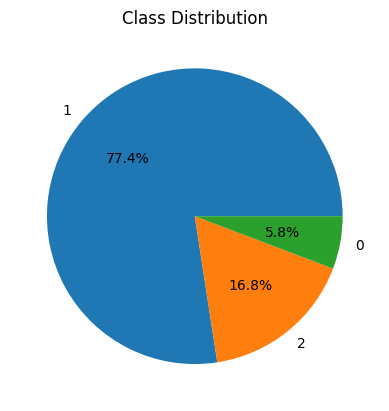

In [10]:
import pandas as pd              # for data handling
import matplotlib.pyplot as plt  # for plotting

# Visualize the class distribution
plt.pie(df['class'].value_counts().values,
        labels=df['class'].value_counts().index,
        autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()


In [11]:
data = df[["class","clean_tweet","labels"]]

In [12]:
data

,class,clean_tweet,labels
0,2,rt woman shouldnt complain clean hous amp man ...,Neutral
1,1,rt boy dat coldtyga dwn bad cuffin dat hoe st ...,Offensive
2,1,rt dawg rt ever fuck bitch start cri confus shit,Offensive
3,1,rt look like tranni,Offensive
4,1,rt shit hear might true might faker bitch told ya,Offensive
...,...,...,...
24778,1,you muthafin lie right tl trash mine bibl scri...,Offensive
24779,2,youv gone broke wrong heart babi drove redneck...,Neutral
24780,1,young buck wanna eat dat nigguh like aint fuck...,Offensive
24781,1,youu got wild bitch tellin lie,Offensive


In [13]:
data['class'].value_counts()

class
1    19190
2     4163
0     1430
Name: count, dtype: int64

In [14]:
# balancing the data for better accuracy and 
# Extract classes
hate_df = df[df['labels'] == 'Hate']
offensive_df = df[df['labels'] == 'Offensive'].sample(n=3500, random_state=42)  # Undersample
neutral_df = df[df['labels'] == 'Neutral']

# Upsample 'Hate' to match the count more closely
balanced_df = pd.concat([hate_df, hate_df, hate_df, offensive_df, neutral_df], axis=0).reset_index(drop=True)




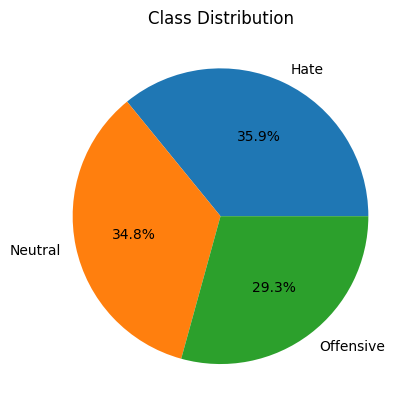

In [15]:
plt.pie(balanced_df['labels'].value_counts().values,
        labels=balanced_df['labels'].value_counts().index,
        autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

# train test split

In [16]:
# importing libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
X = balanced_df['clean_tweet']
y = balanced_df['labels']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [18]:
# vectorizing texts (TF-IDF vectorization)
tfidf = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)


In [19]:
# appling logistic regression 
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

Classification Report:
              precision    recall  f1-score   support

        Hate       0.87      0.86      0.86       858
   Offensive       0.89      0.95      0.92       833
     Neutral       0.85      0.80      0.82       700

    accuracy                           0.87      2391
   macro avg       0.87      0.87      0.87      2391
weighted avg       0.87      0.87      0.87      2391



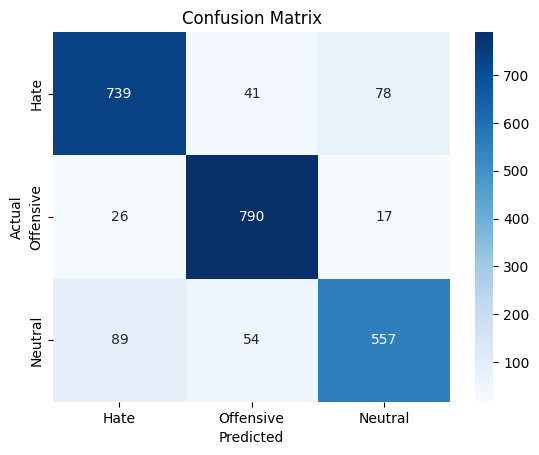

In [20]:
y_pred = clf.predict(X_test_vec)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Hate", "Offensive", "Neutral"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Hate", "Offensive", "Neutral"],
            yticklabels=["Hate", "Offensive", "Neutral"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
sample = "i hate you you stupid ugly cunt od a motherfucking whore"
sample = preprocess_text(sample)

In [22]:
sample

'hate stupid ugli cunt od motherfuck whore'

In [23]:
sample_vec = tfidf.transform([sample])


In [24]:
clf.predict(sample_vec)

array(['Hate'], dtype=object)

# using SVM

In [25]:
#importing libraries
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

In [26]:
#preparing the data
X = balanced_df['clean_tweet']
y = balanced_df['labels']


In [27]:
# vectorizing text
vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)


In [28]:
#spliting data
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)


In [29]:
#Training SVM
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)


c:\Users\eloor\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC()

In [30]:
#valuate the model
y_pred = svm_model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

        Hate       0.87      0.95      0.91       855
     Neutral       0.93      0.92      0.92       824
   Offensive       0.90      0.81      0.85       712

    accuracy                           0.90      2391
   macro avg       0.90      0.89      0.90      2391
weighted avg       0.90      0.90      0.90      2391

Confusion Matrix:
 [[814  10  31]
 [ 34 760  30]
 [ 87  50 575]]


In [31]:
# testing on sample text
def predict_sample(text):
    clean_text = preprocess_text(text)
    vec = vectorizer.transform([clean_text])
    pred = svm_model.predict(vec)[0]
    return pred

# Example:
print(predict_sample("."))


Neutral


# using Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

# Step 1: Define X and y
X = balanced_df['clean_tweet']   
y = balanced_df['labels']        

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Vectorization
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

# Step 4: Random Forest Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 5: Prediction and Evaluation
y_pred = rf.predict(X_test)
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred))



Random Forest Classification Report:

              precision    recall  f1-score   support

        Hate       0.90      0.99      0.95       855
     Neutral       0.95      0.95      0.95       824
   Offensive       0.97      0.86      0.91       712

    accuracy                           0.94      2391
   macro avg       0.94      0.93      0.93      2391
weighted avg       0.94      0.94      0.94      2391



In [33]:

from sklearn.metrics import classification_report, accuracy_score

# Store results
results = {}

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results["Logistic Regression"] = classification_report(y_test, y_pred_lr, output_dict=True)

# Support Vector Machine
svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
results["SVM"] = classification_report(y_test, y_pred_svm, output_dict=True)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results["Random Forest"] = classification_report(y_test, y_pred_rf, output_dict=True)


c:\Users\eloor\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [34]:


# Extract just the 'weighted avg' scores for each model
summary_df = pd.DataFrame({
    model: {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    }
    for model, report, pred in [
        ("Logistic Regression", results["Logistic Regression"], y_pred_lr),
        ("SVM", results["SVM"], y_pred_svm),
        ("Random Forest", results["Random Forest"], y_pred_rf)
    ]
})

summary_df = summary_df.T.round(3)  # Round to 3 decimal places
print(summary_df)


                     Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.885      0.884   0.885     0.884
SVM                     0.906      0.908   0.906     0.905
Random Forest           0.936      0.938   0.936     0.935


<Axes: title={'center': 'Model Performance Comparison'}>

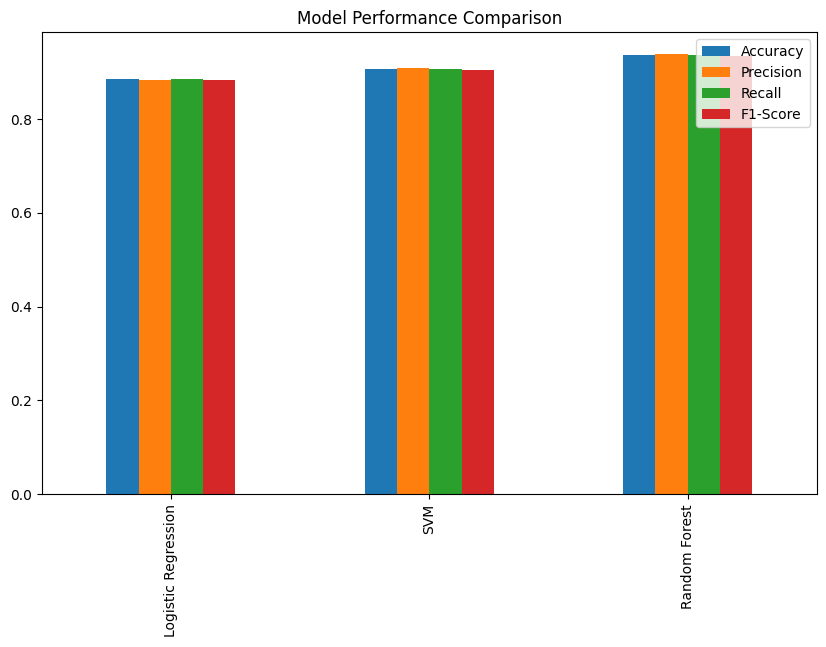

In [35]:
summary_df.plot(kind='bar', figsize=(10, 6), title='Model Performance Comparison')
